<a href="https://colab.research.google.com/github/zeeshan3106/Deep-Learning/blob/main/Artificial%20Neural%20Network%20(With%20Regularization).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler


<Axes: xlabel='Year', ylabel='IT_Jobs_Placed'>

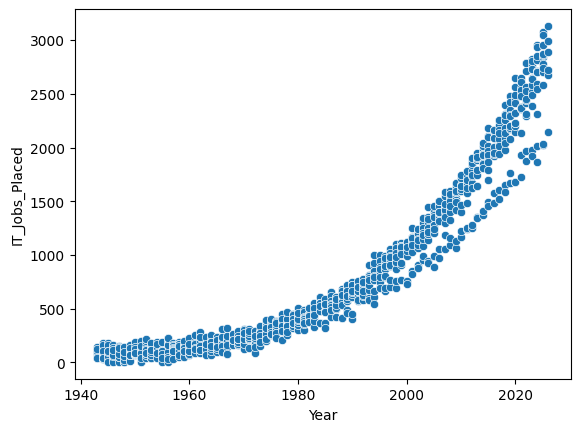

In [103]:
data = pd.read_csv("melbourne_it_jobs_placed.csv")
sns.scatterplot(x = data['Year'],y = data['IT_Jobs_Placed'])


In [104]:
callbacks = EarlyStopping(
    min_delta = 0.001,
    patience = 20,
    restore_best_weights = True

)

In [105]:
model = Sequential()
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X = data.drop("IT_Jobs_Placed",axis=1)
y = data["IT_Jobs_Placed"]
model.add(Dense(64,activation="relu", input_dim=X.shape[1],kernel_regularizer=tensorflow.keras.regularizers.l2(0.01)))
model.add(Dropout(0.2))
model.add(Dense(32,activation="relu", input_dim=X.shape[1],kernel_regularizer=tensorflow.keras.regularizers.l2(0.01)))
model.add(Dropout(0.2))
model.add(Dense(16,activation="relu", input_dim=X.shape[1],kernel_regularizer=tensorflow.keras.regularizers.l2(0.01)))

model.add(Dense(1,activation="linear"))
model.compile(loss="mean_absolute_error",optimizer="adam")

history = model.fit(X_train,y_train,epochs=100,batch_size=1, callbacks=callbacks, validation_data=(X_test,y_test))
from sklearn.metrics import mean_absolute_error
y_pred = model.predict(X_test)
mean_absolute_error(y_test,y_pred)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 441.5501 - val_loss: 137.8595
Epoch 2/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 154.3246 - val_loss: 124.1188
Epoch 3/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 163.0672 - val_loss: 127.8788
Epoch 4/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 153.4653 - val_loss: 115.2652
Epoch 5/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 147.2507 - val_loss: 115.2326
Epoch 6/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 146.7182 - val_loss: 108.4573
Epoch 7/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 145.3200 - val_loss: 117.4157
Epoch 8/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 135.6183 - val_loss: 110.5300
Epoch 9/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 139.3966 - val_loss: 111.4791
Epoch 10/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 141.6001 - val_loss: 103.4329
Epoch 11/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 137.8958 - val_loss: 97.99

75.00458526611328

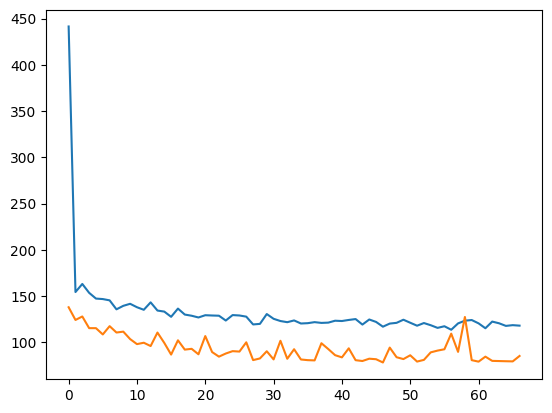

In [108]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])


In [110]:
pred = model.predict(X_test)
mean_absolute_error(y_test,pred)
New={}
New['Predictions']= pd.DataFrame(pred)
New



7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


{'Predictions':                0
 0     394.094025
 1    2001.151978
 2    1171.939209
 3     507.962830
 4     468.017548
 ..           ...
 195  1360.733643
 196   137.569168
 197  1890.860596
 198   736.694336
 199  2563.503906
 
 [200 rows x 1 columns]}